In [1]:
import pandas as pd

from UniversoActivos import UniversoActivosEstatico
from ProveedorDatos import YFinanceProvider
from VariablesTransformation import FeatureEngineer
from Modelos import RandomForestModel
from Estrategia import EstrategiaMLEquiponderada
from Backtest import BacktestEngine

In [2]:
csv_path = r"c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\pipelineJC\data\etfs_by_sector_industry_commodity.csv"

df = pd.read_csv(csv_path)
tickers = df["Ticker"].dropna().astype(str).str.strip().unique().tolist()

In [3]:
universo = UniversoActivosEstatico(tickers=tickers)
proveedor = YFinanceProvider()
fe = FeatureEngineer(criterio=5, ticker_indice="SPY")
modelo = RandomForestModel(positive_class_weight=2.0)
estrategia = EstrategiaMLEquiponderada(modelo=modelo, n_activos_obj=5, umbral_salida=7)

[*********************100%***********************]  42 of 42 completed
[*********************100%***********************]  42 of 42 completed
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\ProveedorDatos.py:48: FutureWarning: DataFrameGroupBy.resample operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly = weekly.agg(Precio_Close=("Precio_Close", "last"), Volumen_USD=("Volumen_USD", "sum")).reset_index()
c:\Users\jpuerta\OneDrive - Analistas Financieros Internacionales (Afi)\Documentos\Master Quant\Gestión de activos\Trabajo gestión cuantitativa\Trabajo_gestion_cuantitativa\VariablesTransformation.py:121: FutureWarn

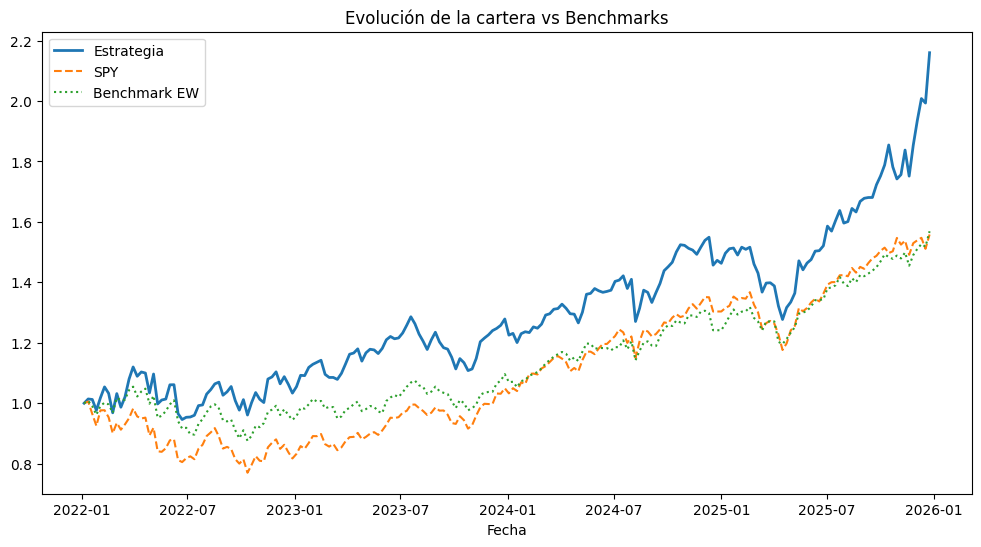

In [5]:
engine = BacktestEngine(
    universo=universo,
    proveedor=proveedor,
    feature_engineer=fe,
    estrategia=estrategia,
    start_date="2020-01-01",
    end_date="2026-01-01",
    len_ventana=2,
    nominal=10000000
)

engine.print_results(bmks=["SPY"], bmk_equal_weight=tickers)